# Feature engineering

Turning each farmer's 52-week series into features across four themes: payment level, consistency, trend, and downside risk. All the logic lives in `src/features.py` as small registered functions; here we just run them and look at what comes out.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.data import load_payments
from src.preprocessing import preprocess
from src.features import build_features, FEATURE_FUNCTIONS

df = preprocess(load_payments())
feats = build_features(df)
print(f'{feats.shape[1]} features for {feats.shape[0]} farmers')
list(FEATURE_FUNCTIONS)

25 features for 1275 farmers


['yearly_total',
 'weekly_mean',
 'weekly_median',
 'max_payment',
 'min_payment',
 'first_13_mean',
 'last_13_mean',
 'std',
 'coef_variation',
 'zero_weeks',
 'active_week_pct',
 'longest_zero_streak',
 'longest_active_streak',
 'trend_slope',
 'recent_vs_history',
 'momentum',
 'rolling_std_mean',
 'min_roll13_mean',
 'p10_payment',
 'p25_payment',
 'downside_deviation',
 'autocorr_lag1',
 'norm_entropy',
 'max_weekly_change',
 'mean_abs_weekly_change']

In [3]:
feats.head()

,yearly_total,weekly_mean,weekly_median,max_payment,min_payment,first_13_mean,last_13_mean,std,coef_variation,zero_weeks,...,momentum,rolling_std_mean,min_roll13_mean,p10_payment,p25_payment,downside_deviation,autocorr_lag1,norm_entropy,max_weekly_change,mean_abs_weekly_change
farmer_no,,,,,,,,,,,,,,,,,,,,,
1,373613.0,7184.865385,0.0,55975.0,0.0,148.230769,604.153846,12850.685202,1.788577,29.0,...,455.923077,9566.187592,0.000000,0.0,0.00,6690.458479,0.673063,0.684850,55975.0,4579.980392
2,506792.0,9746.000000,5129.0,40219.0,0.0,4793.769231,2357.076923,10454.624829,1.072709,7.0,...,-2436.692308,7245.878420,1993.076923,0.0,2675.25,7040.044500,0.814433,0.861452,20691.0,4631.490196
3,344597.0,6626.865385,1984.0,67243.0,0.0,1761.538462,1769.923077,14468.137962,2.183255,6.0,...,8.384615,9917.814459,691.615385,37.3,1165.25,4971.213110,0.868786,0.693848,29782.0,3395.470588
4,3559507.0,68452.057692,15898.0,325712.0,0.0,7626.307692,8003.000000,95577.813360,1.396274,1.0,...,376.692308,59366.199306,7626.307692,1909.6,5207.50,57022.754314,0.933340,0.795179,115397.0,19903.098039
5,67741.0,1302.711538,1076.0,3823.0,0.0,1343.538462,325.923077,1198.025801,0.919640,9.0,...,-1017.615385,875.838646,291.615385,0.0,192.00,1044.099893,0.912526,0.880337,1153.0,366.156863


## Feature distributions

In [4]:
feats.describe().T[['mean','std','min','50%','max']]

,mean,std,min,50%,max
yearly_total,1.434500e+06,2.103440e+06,0.000000,802039.000000,2.637069e+07
weekly_mean,2.758653e+04,4.045077e+04,0.000000,15423.826923,5.071287e+05
weekly_median,2.004770e+04,3.523798e+04,0.000000,9911.500000,4.712845e+05
max_payment,8.968247e+04,1.228675e+05,0.000000,51412.000000,1.253368e+06
min_payment,1.202781e+03,6.734575e+03,0.000000,0.000000,1.645140e+05
first_13_mean,1.711846e+04,3.274298e+04,0.000000,6581.384615,3.380785e+05
last_13_mean,1.210422e+04,2.635014e+04,0.000000,4954.153846,5.330552e+05
std,2.441386e+04,3.377598e+04,0.000000,12951.858474,3.982560e+05
coef_variation,1.000718e+00,5.141986e-01,0.000000,0.903421,7.141428e+00
zero_weeks,9.135686e+00,1.024471e+01,0.000000,6.000000,5.200000e+01


## How features relate to each other
Correlation heatmap. Clusters here tell us which features are redundant.

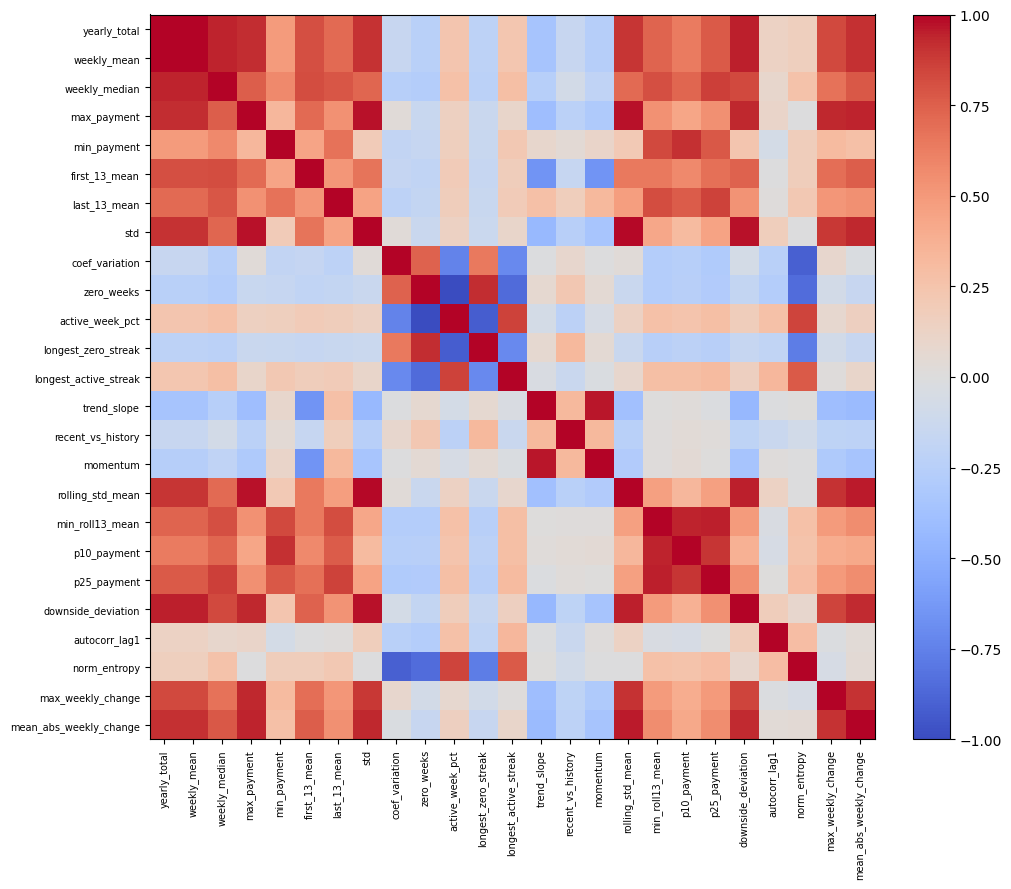

In [5]:
import numpy as np
corr = feats.corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
plt.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout()

The level features (total, mean, max, percentiles) move together, and the consistency features form their own cluster. The risk score deliberately picks a small, spread-out subset so it isn't dominated by one theme.

## Downside features vs the rest
The features that end up mattering most for lending are the downside ones: `min_roll13_mean`, `p10_payment`, `active_week_pct`. Below, farmers with a high active fraction also tend to have a higher worst-quarter average.

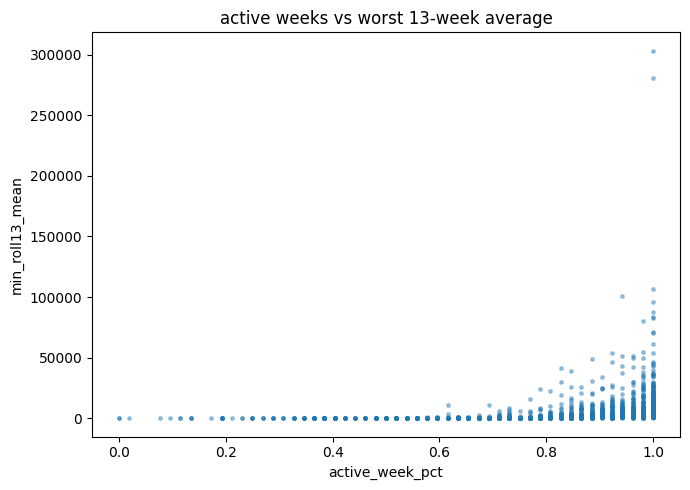

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(feats['active_week_pct'], feats['min_roll13_mean'], s=6, alpha=0.4)
ax.set_xlabel('active_week_pct'); ax.set_ylabel('min_roll13_mean')
ax.set_title('active weeks vs worst 13-week average'); plt.tight_layout()